# 03 · LSTM ทำนายระดับน้ำ X.44 ล่วงหน้า 1–5 วัน

```
ย้อนหลัง 30 วัน × 7 features ──► LSTM (hidden 32) ──► สรุปเป็นเวกเตอร์ 32 ค่า ─┐
 (ระยะจากตลิ่ง 6 สถานี + ฝน)                                                  ├──► Dropout ──► MLP ──► น้ำจะขึ้น/ลงเท่าไร h = 1…5
พยากรณ์ฝน t+1…t+h (5 ค่า) ────────────────────────────────────────────────────┘
                                                        ระดับทำนาย = ระดับวันนี้ + ค่าที่ทำนาย
```
- **LSTM** อ่านข้อมูลทีละวันตามลำดับเวลา จำแนวโน้ม เช่น "ต้นน้ำเริ่มขึ้นมา 2 วันแล้ว ฝนสะสมเยอะ"
- **พยากรณ์ฝน** เข้าหลัง LSTM เพราะเป็นข้อมูลอนาคต ไม่ใช่ส่วนของลำดับย้อนหลัง
- โมเดลเดียวทำนายทั้ง 5 วันพร้อมกัน
- **กันโมเดลจำข้อมูล (overfit):** dropout 0.3 + weight decay + **early stopping** (หยุดเมื่อ validation loss ไม่ดีขึ้น 15 epoch
  แล้วใช้ weight ของ epoch ที่ดีที่สุด)
- loss = MSE ที่ให้น้ำหนักวันน้ำสูง (≥ 3 ม.) มากขึ้น 5 เท่า เพราะวันแบบนี้มีน้อยแต่สำคัญที่สุด

โค้ดโมเดลอยู่ใน `mojito/lstm.py`

In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas
import torch

from mojito import config, evaluation, features, lstm

plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
torch.set_num_threads(6)

HORIZONS = features.HORIZONS
X44_BANK = config.BANK_LEVEL_M["X.44"]
FLOOD_M = evaluation.FLOOD_M  # 7.40 ม. น้ำท่วมพื้นที่ลุ่มต่ำ

table = pandas.read_parquet(config.DATA_DIR / "processed" / "minimal_daily.parquet")
FEATURES = [c for c in table.columns if c.endswith("_bank")] + ["rain"]
RAIN_NEXT = [f"rain_next{h}d" for h in HORIZONS]
days = {
    split: table.index[(table["split"] == split) & table["x44_max"].notna()]
    for split in ("train", "validation", "test")
}
print("features:", FEATURES)
print({split: len(d) for split, d in days.items()})

features: ['x44_bank', 'x90_bank', 'x173a_bank', 'x174_bank', 'sla007_bank', 'sla005_bank', 'rain']
{'train': 1734, 'validation': 273, 'test': 369}


## 1 · ข้อมูลที่ LSTM เห็นต่อ 1 ตัวอย่าง
ทุกวัน t สร้างหน้าต่างย้อนหลัง 30 วัน (t−29 … t) → 1 ตัวอย่าง (`lstm.make_sequences`)

In [2]:
sequences, rain_next, targets, ends = lstm.make_sequences(table, FEATURES, RAIN_NEXT, days["train"])
print(f"ลำดับย้อนหลัง : {sequences.shape}  = (จำนวนตัวอย่าง, 30 วัน, {len(FEATURES)} features)")
print(f"ฝนอนาคต      : {rain_next.shape}  = (จำนวนตัวอย่าง, h = 1…5)")
print(f"target       : {targets.shape}  = (จำนวนตัวอย่าง, น้ำขึ้น/ลง h = 1…5)")

sample_day = pandas.Timestamp("2024-11-27")
i = list(ends).index(sample_day)
pandas.DataFrame(sequences[i][-5:], columns=FEATURES,
                 index=pandas.date_range(end=sample_day, periods=5).date).round(2)

ลำดับย้อนหลัง : (1705, 30, 7)  = (จำนวนตัวอย่าง, 30 วัน, 7 features)
ฝนอนาคต      : (1705, 5)  = (จำนวนตัวอย่าง, h = 1…5)
target       : (1705, 5)  = (จำนวนตัวอย่าง, น้ำขึ้น/ลง h = 1…5)


,x44_bank,x90_bank,x173a_bank,x174_bank,sla007_bank,sla005_bank,rain
2024-11-23,-6.03,-6.34,-5.69,-4.04,-0.79,NaN,12.40
2024-11-24,-5.99,-6.51,-5.69,-3.94,-0.74,NaN,18.73
2024-11-25,-6.00,-6.45,-5.69,-3.97,-0.76,NaN,25.40
2024-11-26,-5.85,-5.70,-4.60,-2.69,-0.60,NaN,37.92
2024-11-27,-2.24,-0.77,-0.10,0.42,-0.17,NaN,82.83


## 2 · เทรน
hyperparameter ตั้งค่าคงที่ (ข้อมูลน้อย ไม่ค้นหา grid) และเทรน 5 รอบด้วย seed ต่างกันแล้ว **เฉลี่ยผล**
เพราะข้อมูลน้อยทำให้ผลแต่ละ seed แกว่งมาก

In [3]:
PARAMS = {"hidden": 32, "dropout": 0.3, "lr": 1e-3, "high_water_weight": 4.0}
MAX_EPOCHS, PATIENCE = 200, 15
SEEDS = range(5)

forecasters = []
for seed in SEEDS:
    model = lstm.LSTMForecaster(FEATURES, RAIN_NEXT, seed=seed, **PARAMS).fit(
        table, days["train"], epochs=MAX_EPOCHS,
        validation_table=table, validation_days=days["validation"], patience=PATIENCE,
    )
    forecasters.append(model)
    print(f"seed {seed}: หยุดที่ epoch {len(model.history)}, ใช้ weight epoch {model.best_epoch}")

seed 0: หยุดที่ epoch 27, ใช้ weight epoch 12


seed 1: หยุดที่ epoch 41, ใช้ weight epoch 26


seed 2: หยุดที่ epoch 38, ใช้ weight epoch 23


seed 3: หยุดที่ epoch 34, ใช้ weight epoch 19


seed 4: หยุดที่ epoch 35, ใช้ weight epoch 20


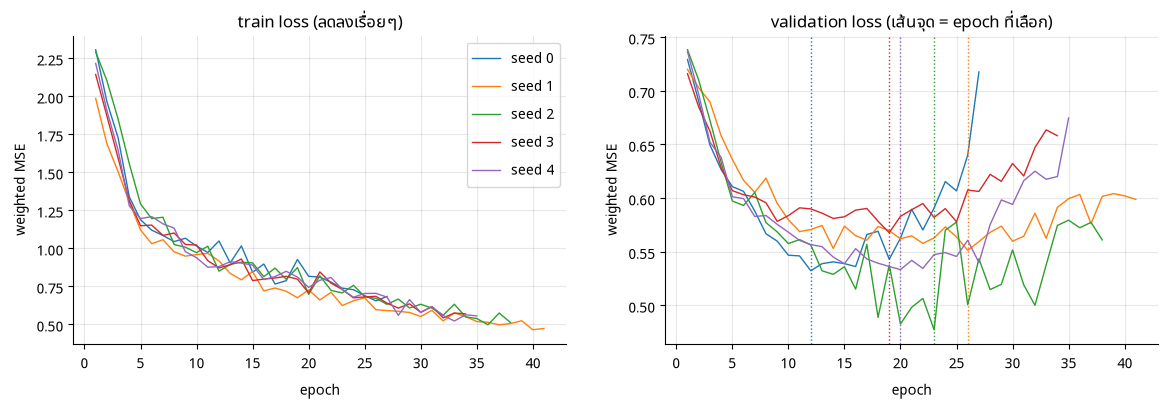

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for seed, model in zip(SEEDS, forecasters):
    color = f"C{seed}"
    epochs = range(1, len(model.history) + 1)
    axes[0].plot(epochs, model.train_history, color=color, lw=1, label=f"seed {seed}")
    axes[1].plot(epochs, model.history, color=color, lw=1)
    axes[1].axvline(model.best_epoch, color=color, ls=":", lw=1)
axes[0].set_title("train loss (ลดลงเรื่อยๆ)")
axes[1].set_title("validation loss (เส้นจุด = epoch ที่เลือก)")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.set_ylabel("weighted MSE")
axes[0].legend()
plt.show()

train loss ลดลงเรื่อยๆ แต่ validation loss ต่ำสุดเร็วแล้วเริ่มสูงขึ้น = โมเดลเริ่มจำข้อมูล train (overfit)
early stopping จึงหยุดและเก็บ weight ช่วงที่ validation ดีที่สุดไว้

## 3 · ผลบน test (ต.ค. 2568 – ปัจจุบัน)
เทียบกับ **persistence** = เดาว่า "อีก h วันน้ำจะเท่าวันนี้" ซึ่งเป็นเกณฑ์ขั้นต่ำที่โมเดลต้องชนะ
- **MAE ทุกวัน:** คลาดเฉลี่ยกี่เมตร (วันน้ำปกติเป็นส่วนใหญ่)
- **MAE วันน้ำหลาก:** เฉพาะวันที่ระดับจริง ≥ 4 ม. — ตัวชี้วัดหลัก
- **เตือนถูก / เตือนผิด:** ทำนาย ≥ 7.40 ม. (ท่วมพื้นที่ลุ่มต่ำ) ตรงกับวันที่ท่วมจริงกี่วัน

In [5]:
def ensemble_predict(split):
    return sum(model.predict(table, days[split]) for model in forecasters) / len(forecasters)


prediction = {split: ensemble_predict(split) for split in ("validation", "test")}
test = table.loc[days["test"]]

rows = []
for h in HORIZONS:
    for name, pred in [("persistence", evaluation.persistence(test, h)), ("LSTM", prediction["test"][f"h{h}"])]:
        rows.append({"h": h, "model": name, **evaluation.scores(pred, test, h)})
results = pandas.DataFrame(rows)
(results.set_index(["model", "h"]).drop(columns="วันท่วมจริง").unstack("h").round(2)
 .rename_axis(columns=["", "h (วัน)"]))

MAE ทุกวัน                         MAE วันน้ำหลาก              \
h (วัน)              1     2     3     4     5              1     2     3   
model                                                                       
LSTM              0.15  0.24  0.31  0.38  0.45           0.94  1.46  2.31   
persistence       0.14  0.23  0.30  0.35  0.39           1.35  2.51  3.61   

                        เตือนถูก             เตือนผิด              
h (วัน)         4     5        1  2  3  4  5        1  2  3  4  5  
model                                                              
LSTM         2.94  3.38        5  5  3  2  1        0  1  1  2  1  
persistence  4.24  4.78        5  4  3  2  1        1  2  3  4  5

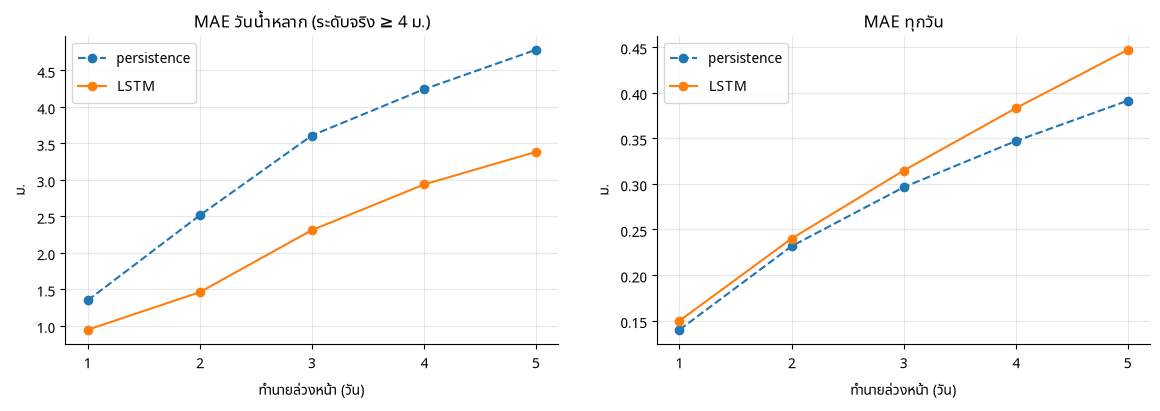

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, style in [("persistence", "--"), ("LSTM", "-")]:
    part = results[results["model"] == name]
    axes[0].plot(part["h"], part["MAE วันน้ำหลาก"], style, marker="o", label=name)
    axes[1].plot(part["h"], part["MAE ทุกวัน"], style, marker="o", label=name)
axes[0].set_title("MAE วันน้ำหลาก (ระดับจริง ≥ 4 ม.)")
axes[1].set_title("MAE ทุกวัน")
for ax in axes:
    ax.set_xlabel("ทำนายล่วงหน้า (วัน)")
    ax.set_ylabel("ม.")
    ax.set_xticks(list(HORIZONS))
    ax.legend()
plt.show()

## 4 · เหตุการณ์น้ำท่วม พ.ย. 2568
เส้นทำนายถูกเลื่อนไปที่ **วันที่ถูกทำนาย** (ไม่ใช่วันที่ออกพยากรณ์) เพื่อเทียบกับระดับจริงวันเดียวกัน
แกนขวาเป็นระยะจากตลิ่ง X.44

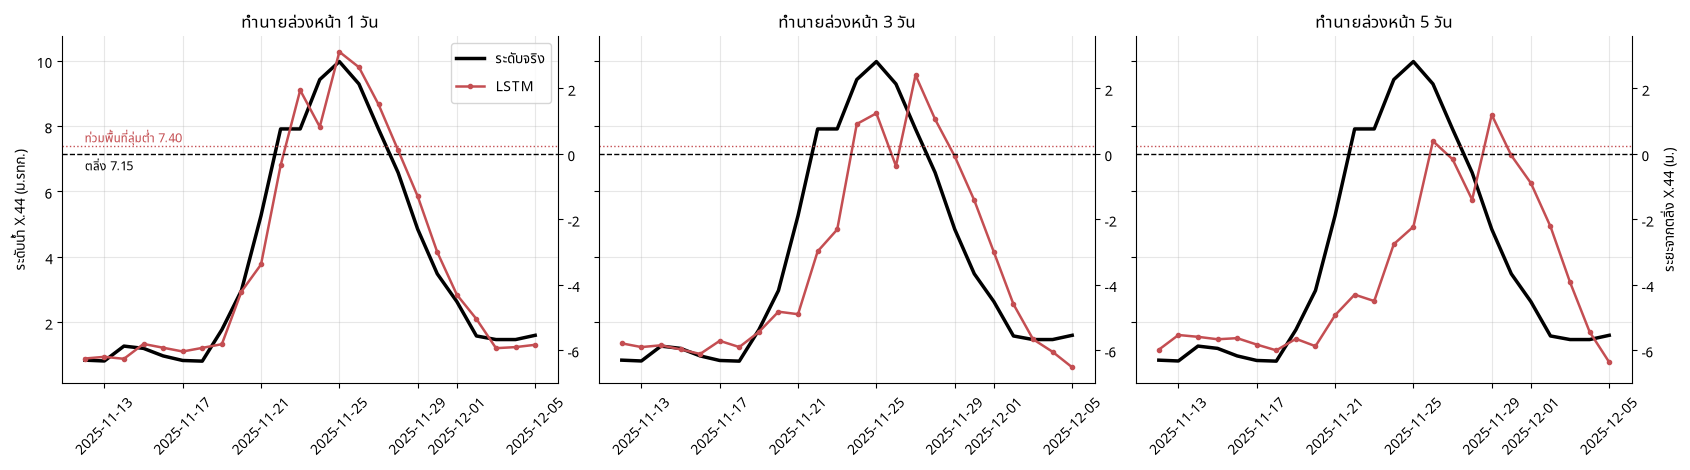

In [7]:
event = slice("2025-11-12", "2025-12-05")
actual = table["x44_max"].loc[event]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, h in zip(axes, (1, 3, 5)):
    shifted = prediction["test"][f"h{h}"].copy()
    shifted.index = shifted.index + pandas.Timedelta(days=h)
    ax.plot(actual.index, actual, color="k", lw=2.5, label="ระดับจริง")
    ax.plot(shifted.loc[event].index, shifted.loc[event], color="#c44e52", lw=1.8, marker=".", label="LSTM")
    ax.axhline(X44_BANK, color="k", ls="--", lw=1)
    ax.axhline(FLOOD_M, color="#c44e52", ls=":", lw=1)
    ax.set_title(f"ทำนายล่วงหน้า {h} วัน")
    ax.tick_params(axis="x", rotation=45)
    right = ax.secondary_yaxis("right", functions=(lambda y: y - X44_BANK, lambda y: y + X44_BANK))
    if h == 5:
        right.set_ylabel("ระยะจากตลิ่ง X.44 (ม.)")
axes[0].set_ylabel("ระดับน้ำ X.44 (ม.รทก.)")
axes[0].text(actual.index[0], X44_BANK - 0.1, "ตลิ่ง 7.15", fontsize=9, va="top")
axes[0].text(actual.index[0], FLOOD_M + 0.1, "ท่วมพื้นที่ลุ่มต่ำ 7.40", fontsize=9, color="#c44e52")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

In [8]:
# ตารางรายวันช่วงพีค: ทำนายเมื่อ h วันก่อน เทียบระดับจริง (ระยะจากตลิ่ง, ม.)
peak_days = pandas.date_range("2025-11-20", "2025-11-29")
peak_table = pandas.DataFrame({"จริง": table["x44_max"].reindex(peak_days) - X44_BANK})
for h in (1, 3, 5):
    shifted = prediction["test"][f"h{h}"].copy()
    shifted.index = shifted.index + pandas.Timedelta(days=h)
    peak_table[f"ทำนายล่วงหน้า {h} วัน"] = shifted.reindex(peak_days) - X44_BANK
peak_table.index = peak_table.index.date
peak_table.round(2)

,จริง,ทำนายล่วงหน้า 1 วัน,ทำนายล่วงหน้า 3 วัน,ทำนายล่วงหน้า 5 วัน
2025-11-20,-4.18,-4.21,-4.83,-5.88
2025-11-21,-1.89,-3.38,-4.90,-4.94
2025-11-22,0.76,-0.36,-2.99,-4.31
2025-11-23,0.76,1.94,-2.31,-4.50
2025-11-24,2.27,0.82,0.91,-2.76
2025-11-25,2.82,3.12,1.24,-2.23
2025-11-26,2.13,2.65,-0.37,0.39
2025-11-27,0.75,1.51,2.40,-0.17
2025-11-28,-0.58,0.11,1.05,-1.40
2025-11-29,-2.31,-1.30,-0.08,1.19


## 5 · สรุป
**LSTM + ระยะจากตลิ่ง + พยากรณ์ฝน ทำนายช่วงน้ำหลากได้ดีกว่า persistence ทุก horizon**

| ทำนายล่วงหน้า | 1 วัน | 2 วัน | 3 วัน | 4 วัน | 5 วัน |
|---|---|---|---|---|---|
| MAE วันน้ำหลาก LSTM (ม.) | **0.94** | **1.46** | **2.31** | **2.94** | **3.38** |
| MAE วันน้ำหลาก persistence (ม.) | 1.35 | 2.51 | 3.61 | 4.24 | 4.78 |
| เตือน ≥ 7.40 ม. ถูก (จาก 6 วัน) LSTM | 5 | 5 | 3 | 2 | 1 |
| เตือนผิด LSTM / persistence | 0 / 1 | 1 / 2 | 1 / 3 | 2 / 4 | 1 / 5 |

- **ล่วงหน้า 1 วัน** ตามน้ำขึ้นได้ใกล้เคียงจริง รวมถึงพีค 9.97 ม. ที่สูงกว่าทุกอย่างใน train (เพราะทำนายการเปลี่ยนแปลง)
- **ล่วงหน้า 3–5 วัน** เห็นว่าน้ำจะขึ้น แต่ทำนายพีคต่ำและช้ากว่าจริง เพราะพยากรณ์ฝน GFS ให้ฝนหนักน้อยกว่าจริงมาก
- **การเตือน ≥ 7.40 ม.** จำนวนวันที่เตือนถูกเท่ากับ persistence (5/4/3/2/1) แต่เตือนผิดน้อยกว่ามาก (รวม 5 vs 15 ครั้ง)
- **วันน้ำปกติ** MAE ทุกวันพอๆ กับ persistence (0.15–0.45 ม.) — วันปกติน้ำแทบไม่เปลี่ยน persistence จึงชนะได้ยาก
- **early stopping** หยุดที่ epoch 27–41 และใช้ weight epoch 12–26: เกินจากนั้น train loss ลดต่อแต่ validation loss เพิ่ม = overfit

**ข้อจำกัด**
1. น้ำท่วมใหญ่ใน test มีแค่ครั้งเดียว (6 วันท่วม) ตัวเลขจึงแกว่งได้มาก
2. validation (ม.ค.–ก.ย. 2568) ไม่มีวันน้ำหลาก — early stopping ตัดสินจากวันปกติ
3. train ใช้ฝนอนาคตที่ตกจริง แต่ test ใช้พยากรณ์ซึ่งต่ำกว่าจริง → โมเดลเห็นฝนน้อยกว่าที่เรียนมา
4. SLA005 ขาดข้อมูลช่วง 2567 – ก.ย. 2568